# Anexo: Transformación de Columnas

**Fundamentos de Aprendizaje Automático**

One Hot Encoding

In [6]:
import pandas as pd

data = {
    'Region': ['Norte', 'Norte', 'Sur', 'Sur', 'Norte', 'Norte', 'Sur', 'Sur'],
    'Mes': ['Enero', 'Febrero', 'Enero', 'Febrero', 'Enero', 'Febrero', 'Enero', 'Febrero'],
    'Producto': ['Televisor', 'Televisor', 'Televisor', 'Televisor', 'Radio', 'Radio', 'Radio', 'Radio'],
    'Ventas': [1500, 1200, 900, 1100, 400, 450, 300, 320]
}

df = pd.DataFrame(data)

print(df)

# Creamos el pivote
pivote_ventas = df.pivot_table(
    index='Region',    # Lo que queremos en las filas
    columns='Mes',     # Lo que queremos en las columnas
    values='Ventas',   # El dato numérico que vamos a analizar
    aggfunc='sum'      # Si hay varios registros, que los sume
)

print(" ")
print(pivote_ventas)

  Region      Mes   Producto  Ventas
0  Norte    Enero  Televisor    1500
1  Norte  Febrero  Televisor    1200
2    Sur    Enero  Televisor     900
3    Sur  Febrero  Televisor    1100
4  Norte    Enero      Radio     400
5  Norte  Febrero      Radio     450
6    Sur    Enero      Radio     300
7    Sur  Febrero      Radio     320
 
Mes     Enero  Febrero
Region                
Norte    1900     1650
Sur      1200     1420


In [7]:
# Dataset de ejemplo
data = {'ID': [1, 2, 3, 4],
        'Color': ['Rojo', 'Verde', 'Azul', 'Rojo']}
df = pd.DataFrame(data)

# Aplicamos One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['Color'])

print(df_encoded)

   ID  Color_Azul  Color_Rojo  Color_Verde
0   1       False        True        False
1   2       False       False         True
2   3        True       False        False
3   4       False        True        False


Label encoding

In [8]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# 1. Datos de ejemplo
df = pd.DataFrame({'Nivel': ['Bajo', 'Medio', 'Alto', 'Bajo', 'Alto']})

# 2. Inicializar y aplicar el encoder
le = LabelEncoder()
df['Nivel_Encoded'] = le.fit_transform(df['Nivel'])

print(df)

   Nivel  Nivel_Encoded
0   Bajo              1
1  Medio              2
2   Alto              0
3   Bajo              1
4   Alto              0


Agrupar las categorías menos frecuentes

In [9]:
import pandas as pd

# 1. Creamos un dataset de ejemplo
data = {'Ciudad': ['Madrid', 'Madrid', 'Madrid', 'Bogotá', 'Bogotá', 'CDMX', 'Tokio', 'Oslo', 'París', 'Seúl']}
df = pd.DataFrame(data)

# 2. Definimos un umbral (threshold)
# En este caso, si la ciudad aparece menos de 2 veces, será "Otros"
umbral = 2
frecuencias = df['Ciudad'].value_counts()

# 3. Identificamos las categorías que no cumplen el umbral
categorias_infrecuentes = frecuencias[frecuencias < umbral].index

# 4. Reemplazamos esas categorías
df['Ciudad_Agrupada'] = df['Ciudad'].replace(categorias_infrecuentes, 'Otros')

print("Frecuencias originales:")
print(frecuencias)
print("\nDataset resultante:")
print(df)

Frecuencias originales:
Ciudad
Madrid    3
Bogotá    2
CDMX      1
Tokio     1
Oslo      1
París     1
Seúl      1
Name: count, dtype: int64

Dataset resultante:
   Ciudad Ciudad_Agrupada
0  Madrid          Madrid
1  Madrid          Madrid
2  Madrid          Madrid
3  Bogotá          Bogotá
4  Bogotá          Bogotá
5    CDMX           Otros
6   Tokio           Otros
7    Oslo           Otros
8   París           Otros
9    Seúl           Otros


Binary encoding

In [10]:
%pip install category_encoders

Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd
import category_encoders as ce

# 1. Creamos un dataset con muchas categorías
data = {'Producto': ['Laptop', 'Mouse', 'Monitor', 'Teclado', 'Cable', 'Cámara', 'Micro', 'Silla']}
df = pd.DataFrame(data)

# 2. Inicializamos el codificador binario
encoder = ce.BinaryEncoder(cols=['Producto'])

# 3. Transformamos los datos
df_binary = encoder.fit_transform(df)

print("Dataset Original:")
print(df)
print("\nDataset con Binary Encoding:")
print(df_binary)

Dataset Original:
  Producto
0   Laptop
1    Mouse
2  Monitor
3  Teclado
4    Cable
5   Cámara
6    Micro
7    Silla

Dataset con Binary Encoding:
   Producto_0  Producto_1  Producto_2  Producto_3
0           0           0           0           1
1           0           0           1           0
2           0           0           1           1
3           0           1           0           0
4           0           1           0           1
5           0           1           1           0
6           0           1           1           1
7           1           0           0           0


**Correlación**

La correlación entre horas de estudio y calificación es: 0.9917

Matriz de correlación:
               horas_estudio  calificacion  cafe_tomado
horas_estudio       1.000000      0.991712     0.787087
calificacion        0.991712      1.000000     0.843211
cafe_tomado         0.787087      0.843211     1.000000


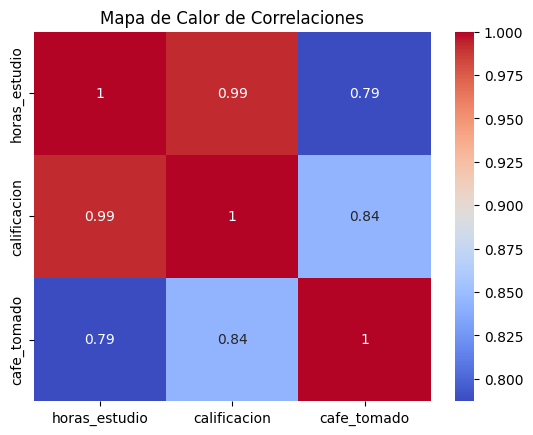

In [12]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Creamos un dataset de ejemplo
data = {
    'horas_estudio': [2, 9, 5, 1, 8, 10, 4, 7],
    'calificacion': [55, 92, 70, 45, 88, 95, 62, 85],
    'cafe_tomado': [1, 5, 2, 0, 4, 3, 2, 6]
}

df = pd.DataFrame(data)

# 2. Calcular la correlación entre dos columnas específicas
correlacion_especifica = df['horas_estudio'].corr(df['calificacion'])

print(f"La correlación entre horas de estudio y calificación es: {correlacion_especifica:.4f}")

# 3. Ver la matriz de correlación completa
matriz_corr = df.corr()
print("\nMatriz de correlación:")
print(matriz_corr)

# Dibujar el mapa de calor
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Mapa de Calor de Correlaciones")
plt.show()

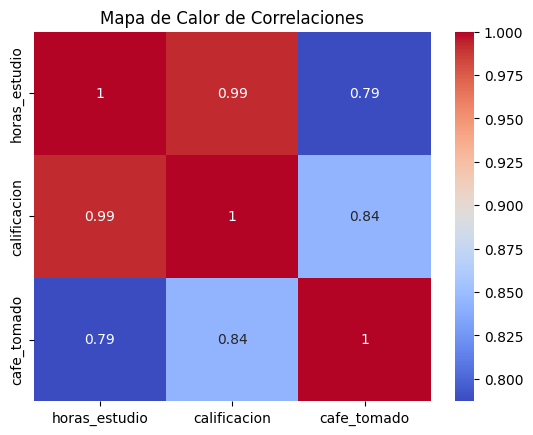

In [13]:
# Dibujar el mapa de calor
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Mapa de Calor de Correlaciones")
plt.show()

Pearson, Spearman

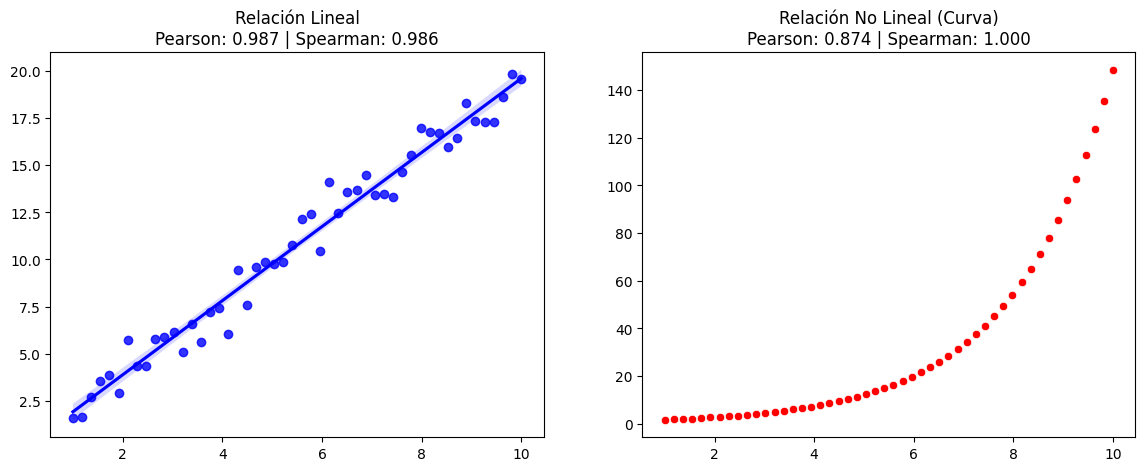

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creamos datos
x = np.linspace(1, 10, 50)

# Relación LINEAL (Línea recta con un poco de ruido)
y_lineal = 2 * x + np.random.normal(0, 1, 50)

# Relación NO LINEAL / MONOTÓNICA (Exponencial: siempre sube, pero en curva)
y_curva = np.exp(x/2)

# 2. Calculamos correlaciones
corr_p_lin = pd.Series(x).corr(pd.Series(y_lineal), method='pearson')
corr_s_lin = pd.Series(x).corr(pd.Series(y_lineal), method='spearman')

corr_p_curv = pd.Series(x).corr(pd.Series(y_curva), method='pearson')
corr_s_curv = pd.Series(x).corr(pd.Series(y_curva), method='spearman')

# 3. Graficamos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico Lineal
sns.regplot(x=x, y=y_lineal, ax=ax1, color='blue')
ax1.set_title(f'Relación Lineal\nPearson: {corr_p_lin:.3f} | Spearman: {corr_s_lin:.3f}')

# Gráfico Curvo (Monotónico)
sns.scatterplot(x=x, y=y_curva, ax=ax2, color='red')
ax2.set_title(f'Relación No Lineal (Curva)\nPearson: {corr_p_curv:.3f} | Spearman: {corr_s_curv:.3f}')

plt.show()

**Escalamiento**

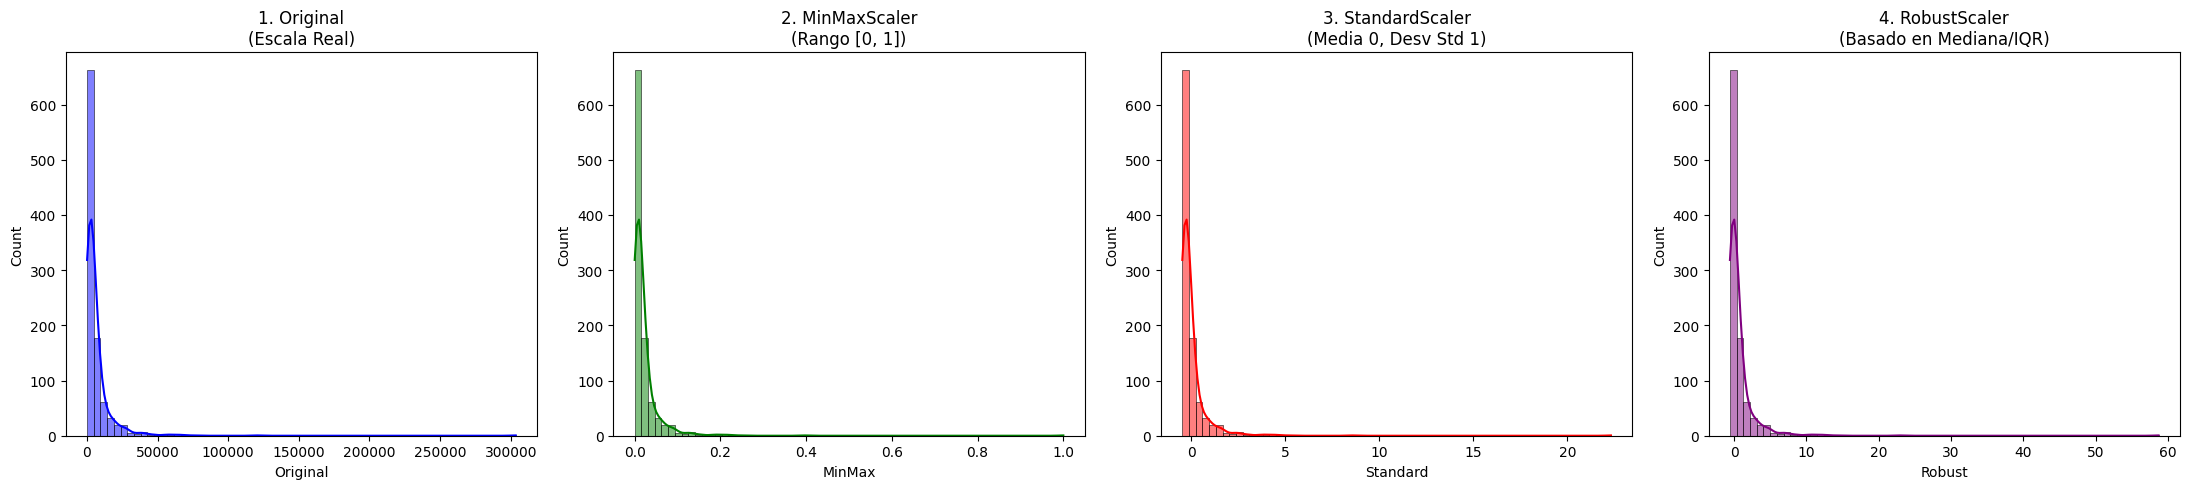

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# 1. Crear 1,000 datos (Distribución con outliers agresivos)
np.random.seed(42)
datos = np.random.lognormal(mean=8, sigma=1.2, size=1000).reshape(-1, 1)
df = pd.DataFrame(datos, columns=['Original'])

# 2. Aplicar los 3 escaladores
df['MinMax'] = MinMaxScaler().fit_transform(df[['Original']])
df['Standard'] = StandardScaler().fit_transform(df[['Original']])
df['Robust'] = RobustScaler().fit_transform(df[['Original']])

# 3. Graficar Histogramas
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Histograma Original
sns.histplot(df['Original'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('1. Original\n(Escala Real)')

# Histograma MinMax
sns.histplot(df['MinMax'], kde=True, ax=axes[1], color='green')
axes[1].set_title('2. MinMaxScaler\n(Rango [0, 1])')

# Histograma StandardScaler
sns.histplot(df['Standard'], kde=True, ax=axes[2], color='red')
axes[2].set_title('3. StandardScaler\n(Media 0, Desv Std 1)')

# Histograma RobustScaler
sns.histplot(df['Robust'], kde=True, ax=axes[3], color='purple')
axes[3].set_title('4. RobustScaler\n(Basado en Mediana/IQR)')

plt.tight_layout()
plt.show()

**Transformación logarítmica**

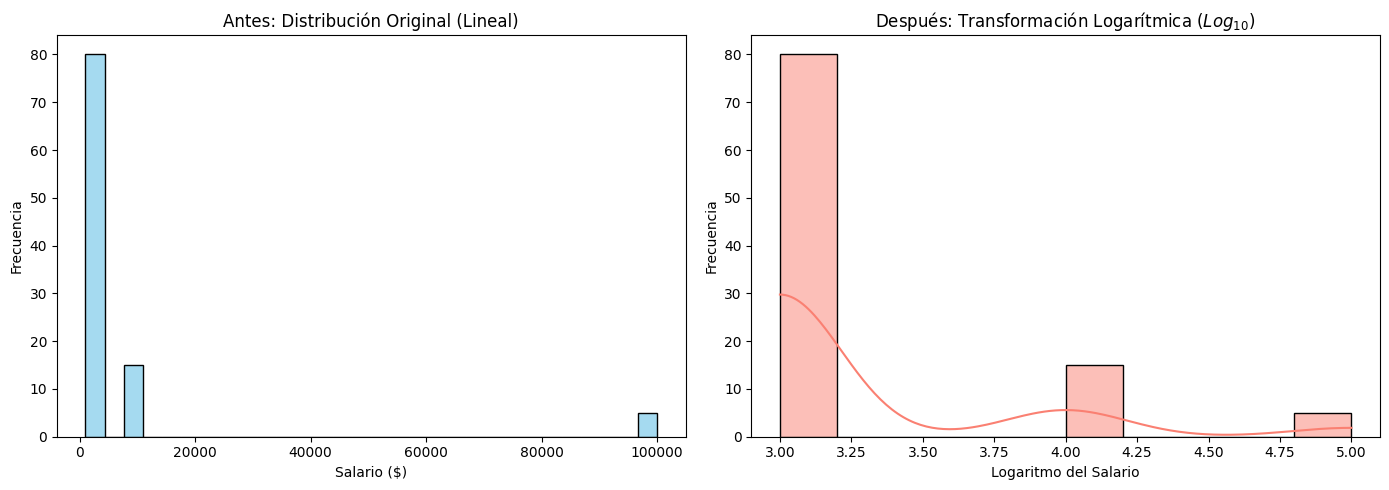

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Crear datos simulados
# 80 veces A(1000), 15 veces B(10000), 5 veces C(100000)
data = ([1000] * 80) + ([10000] * 15) + ([100000] * 5)
df = pd.DataFrame(data, columns=['Salario'])

# 2. Aplicar transformación logarítmica (Log10 para que sea legible)
df['Log_Salario'] = np.log10(df['Salario'])

# 3. Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Antes de la transformación (Escala Lineal)
sns.histplot(df['Salario'], bins=30, kde=False, ax=axes[0], color='skyblue')
axes[0].set_title('Antes: Distribución Original (Lineal)')
axes[0].set_xlabel('Salario ($)')
axes[0].set_ylabel('Frecuencia')

# Gráfica 2: Después de la transformación (Escala Logarítmica)
sns.histplot(df['Log_Salario'], bins=10, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Después: Transformación Logarítmica ($Log_{10}$)')
axes[1].set_xlabel('Logaritmo del Salario')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Modelo sin logaritmo y con logaritmo usando regresión

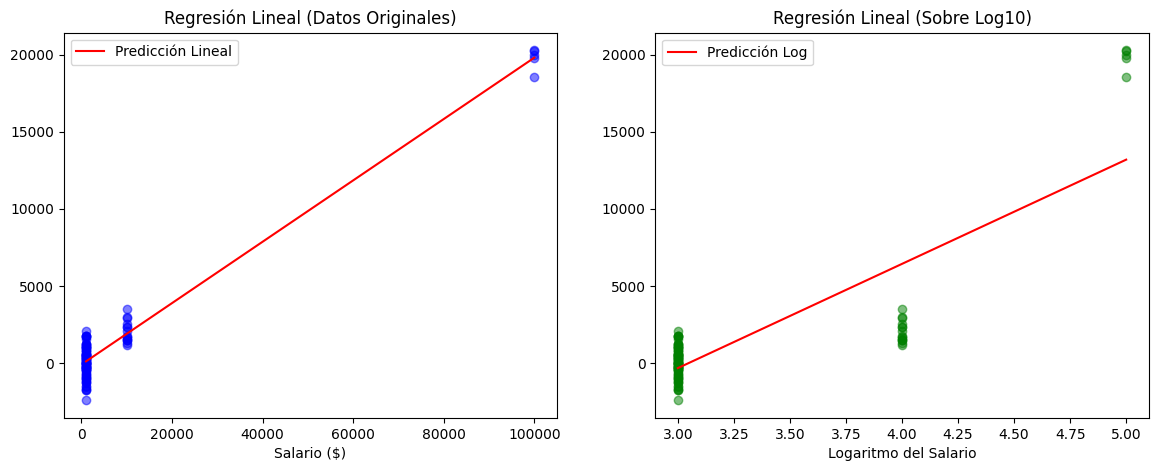

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Crear datos: Salarios y un "Gasto" relacionado (con algo de ruido)
np.random.seed(42)
salarios = np.array(([1000] * 80) + ([10000] * 15) + ([100000] * 5)).reshape(-1, 1)
# El gasto es aprox el 20% del salario + ruido
gasto = 0.2 * salarios + np.random.normal(0, 1000, salarios.shape)

# 2. Modelo con datos ORIGINALES
modelo_lineal = LinearRegression().fit(salarios, gasto)
pred_lineal = modelo_lineal.predict(salarios)

# 3. Modelo con datos LOGARÍTMICOS
log_salarios = np.log10(salarios)
modelo_log = LinearRegression().fit(log_salarios, gasto)
pred_log = modelo_log.predict(log_salarios)

# 4. Visualización de la diferencia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica Lineal: El outlier "jala" la línea hacia arriba
axes[0].scatter(salarios, gasto, color='blue', alpha=0.5)
axes[0].plot(salarios, pred_lineal, color='red', label='Predicción Lineal')
axes[0].set_title('Regresión Lineal (Datos Originales)')
axes[0].set_xlabel('Salario ($)')
axes[0].legend()

# Gráfica Logarítmica: La línea entiende mejor la progresión
axes[1].scatter(log_salarios, gasto, color='green', alpha=0.5)
axes[1].plot(log_salarios, pred_log, color='red', label='Predicción Log')
axes[1].set_title('Regresión Lineal (Sobre Log10)')
axes[1].set_xlabel('Logaritmo del Salario')
axes[1].legend()

plt.show()

**Aplicación modelo**

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# 1. CREACIÓN DEL CONJUNTO DE DATOS
np.random.seed(42)
n_samples = 1000

data = []
for i in range(n_samples):
    clase = np.random.randint(0, 4)
    # Generamos Precio y Peso con escalas muy diferentes
    if clase == 0: # Barato, Ligero
        precio, peso = np.random.normal(500, 150), np.random.normal(2, 0.8)
    elif clase == 1: # Caro, Pesado
        precio, peso = np.random.normal(4000, 600), np.random.normal(8, 1.2)
    elif clase == 2: # Barato, Pesado
        precio, peso = np.random.normal(700, 200), np.random.normal(7, 1.5)
    else: # Caro, Ligero
        precio, peso = np.random.normal(3500, 500), np.random.normal(3, 1)

    data.append([precio, peso, clase])

df = pd.DataFrame(data, columns=['Precio', 'Peso', 'Categoria'])

# 2. PREPARACIÓN
X = df[['Precio', 'Peso']]
y = df['Categoria']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. ESCALAMIENTO
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. ENTRENAMIENTO CON KNN
#algorithm = KNeighborsClassifier(n_neighbors=7)
#algorithm.fit(X_train_scaled, y_train)

# 4.1 ENTRENAMIENTO CON SVM
#algorithm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
#algorithm.fit(X_train_scaled, y_train)

# 4.2 ENTRENAMIENTO CON RANDOM FOREST
algorithm = RandomForestClassifier(n_estimators=100, random_state=42)
algorithm.fit(X_train_scaled, y_train)


# 5. PREDICCIÓN Y ACCURACY
y_pred = algorithm.predict(X_test_scaled)
precisión_total = accuracy_score(y_test, y_pred)

# --- RESULTADOS ---
print(f"--- RESULTADOS DEL ALGORITMO ---")
print(f"Accuracy Global: {precisión_total * 100:.2f}%")
print("-" * 33)
#print("\nReporte de Clasificación:")
#print(classification_report(y_test, y_pred, target_names=['Barato/Lig', 'Caro/Pes', 'Barato/Pes', 'Caro/Lig']))

# 6. VISUALIZACIÓN
#plt.figure(figsize=(10, 6))
#cm = confusion_matrix(y_test, y_pred)
#sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#            xticklabels=['Barato/Lig', 'Caro/Pes', 'Barato/Pes', 'Caro/Lig'],
#            yticklabels=['Barato/Lig', 'Caro/Pes', 'Barato/Pes', 'Caro/Lig'])
#plt.title(f'Matriz de Confusión (Accuracy: {precisión_total:.4f})')
#plt.ylabel('Realidad')
#plt.xlabel('Predicción')
#plt.show()

--- RESULTADOS DEL ALGORITMO ---
Accuracy Global: 97.50%
---------------------------------


In [19]:
df

,Precio,Peso,Categoria
0,589.953102,7.773150,2
1,2944.059941,3.318902,3
2,681.075800,5.606758,2
3,736.881922,2.613948,0
4,4047.899087,7.808580,1
...,...,...,...
995,3603.633665,3.069344,3
996,462.817798,7.517346,2
997,683.323145,7.278539,2
998,3759.364690,10.244796,1
